In [4]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
import pandas as pd

df = pd.read_csv("../data/marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df["Income"].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

In [10]:
df["Income"].sort_values(ascending=False).head(10)

2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64

In [11]:
df["Income"].median()

51381.5

In [12]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [13]:
df["Income"].isnull().sum()

np.int64(0)

In [14]:
df[df["Income"] == 666666]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0


In [15]:
df.loc[df["Income"] == 666666,
    ["Income",
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
        "NumStorePurchases",
        "NumWebPurchases",
        "Z_Revenue"]]

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebPurchases,Z_Revenue
2233,666666.0,9,14,18,8,1,12,3,3,11


In [16]:
df = df[df["Income"] < 300000]

In [17]:
df["Income"].max()

162397.0

In [18]:
df.shape

(2239, 29)

In [19]:
df["Age"] = 2026 - df["Year_Birth"]

df["Age"].describe()

count    2239.000000
mean       57.197856
std        11.985494
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

In [20]:
df[df["Age"] > 100][["Year_Birth", "Age", "Income"]]

,Year_Birth,Age,Income
192,1900,126,36640.0
239,1893,133,60182.0
339,1899,127,83532.0


In [21]:
df = df[df["Age"] <= 100]

In [22]:
df["Age"].describe()

count    2236.000000
mean       57.101968
std        11.703281
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max        86.000000
Name: Age, dtype: float64

In [23]:
df.shape

(2236, 30)

In [24]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [25]:
df["Total_Children"].value_counts()

Total_Children
1    1125
0     637
2     421
3      53
Name: count, dtype: int64

In [26]:
df.shape

(2236, 31)

In [27]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df["Total_Spending"].describe()

count    2236.000000
mean      605.986583
std       601.865156
min         5.000000
25%        69.000000
50%       396.500000
75%      1045.500000
max      2525.000000
Name: Total_Spending, dtype: float64

In [28]:
Q1 = df["Total_Spending"].quantile(0.25)
Q3 = df["Total_Spending"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

df[df["Total_Spending"] > upper].shape

Lower Bound: -1395.75
Upper Bound: 2510.25


(3, 32)

In [29]:
df[df["Total_Spending"] > upper].shape

(3, 32)

In [30]:
df[df["Total_Spending"] > upper][
    ["Income", "Age", "Total_Spending", "NumStorePurchases", "NumWebPurchases"]
]

,Income,Age,Total_Spending,NumStorePurchases,NumWebPurchases
1179,90638.0,35,2525,10,3
1492,87679.0,38,2524,10,7
1572,90638.0,35,2525,10,3


In [31]:
df.shape

(2236, 32)

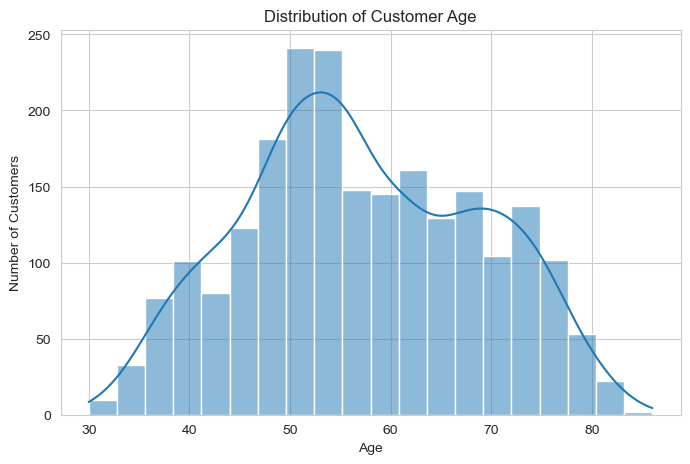

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [33]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [34]:
import seaborn as sns

print(sns.__version__)

0.13.2


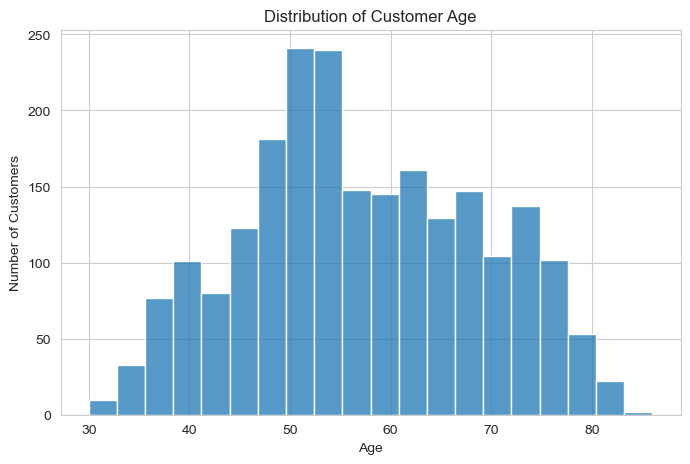

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

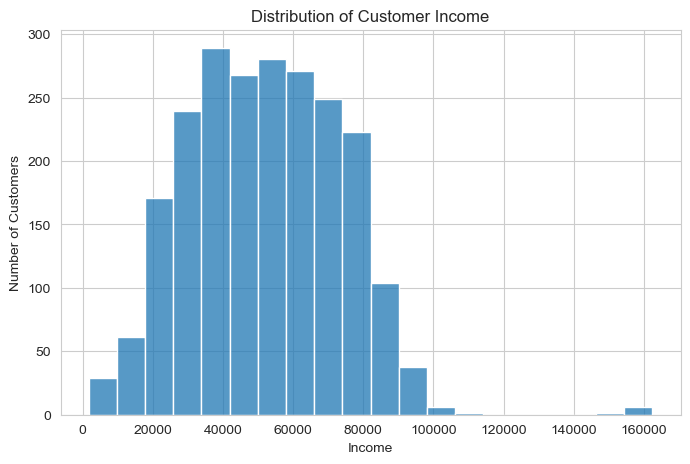

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["Income"], bins=20)

plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

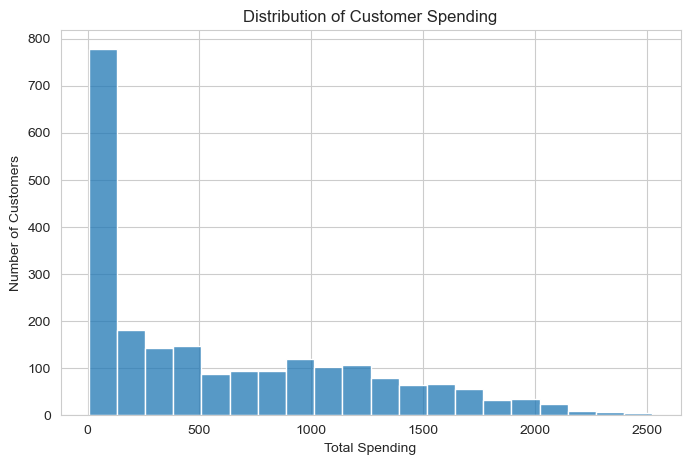

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total_Spending"], bins=20)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

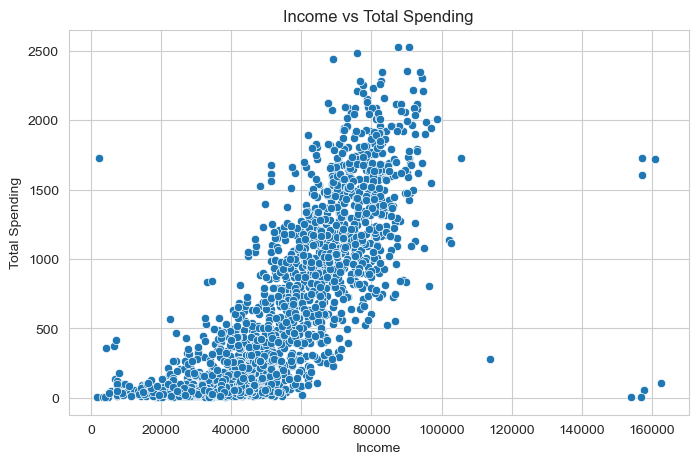

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Income"],
    y=df["Total_Spending"]
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.show()

In [39]:
df.groupby("Total_Children")["Total_Spending"].mean()

Total_Children
0    1104.857143
1     473.861333
2     245.947743
3     274.603774
Name: Total_Spending, dtype: float64

In [40]:
df["Total_Children"].value_counts()

Total_Children
1    1125
0     637
2     421
3      53
Name: count, dtype: int64

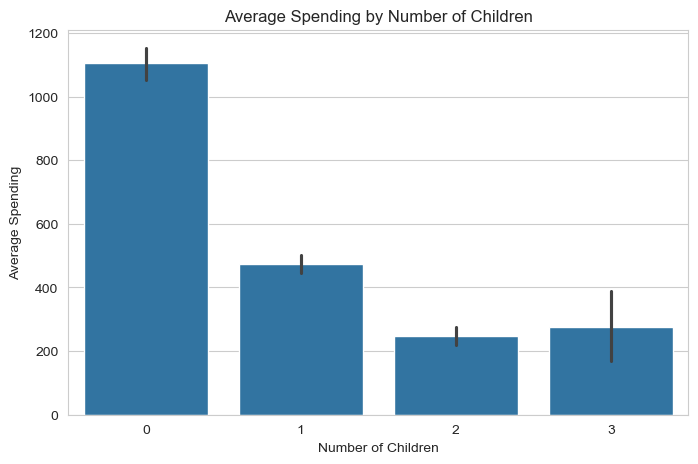

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Total_Children",
    y="Total_Spending",
    data=df
)

plt.title("Average Spending by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Spending")

plt.show()

In [42]:
df[["Age", "Total_Spending"]].corr()

,Age,Total_Spending
Age,1.000000,0.113618
Total_Spending,0.113618,1.000000


In [43]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[30,40,50,60,70,90],
    labels=["30-39","40-49","50-59","60-69","70+"]
)

df.groupby("Age_Group")["Total_Spending"].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_39716\50673410.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Total_Spending"].mean()


Age_Group
30-39    656.818182
40-49    500.914851
50-59    551.859854
60-69    670.674797
70+      742.643836
Name: Total_Spending, dtype: float64

In [44]:
df["Income"].describe()

count      2236.000000
mean      51952.614043
std       21411.466851
min        1730.000000
25%       35502.500000
50%       51381.500000
75%       68275.750000
max      162397.000000
Name: Income, dtype: float64

In [45]:
df["Income_Group"] = pd.cut(
    df["Income"],
    bins=[0,30000,60000,90000,170000],
    labels=["Low","Middle","High","Very High"]
)

df.groupby("Income_Group")["Total_Spending"].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_39716\2576349564.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Income_Group")["Total_Spending"].mean()


Income_Group
Low            72.183784
Middle        303.849222
High         1186.246819
Very High    1606.365385
Name: Total_Spending, dtype: float64

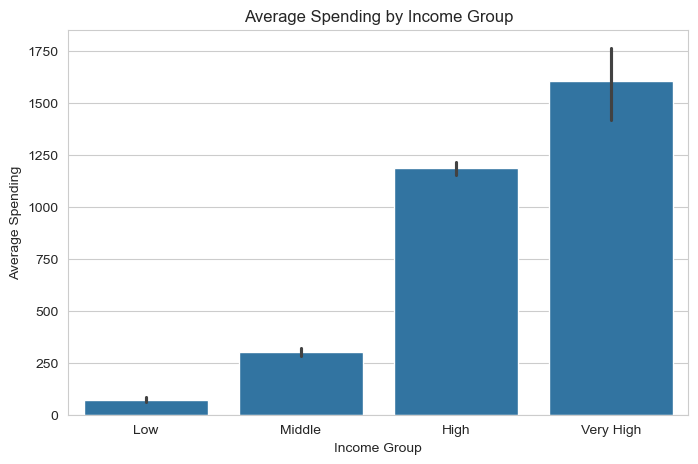

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Income_Group",
    y="Total_Spending",
    data=df
)

plt.title("Average Spending by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Spending")

plt.show()

In [47]:
df[["Income", "Total_Spending"]].corr()

,Income,Total_Spending
Income,1.000000,0.789375
Total_Spending,0.789375,1.000000


In [48]:
df["Spending_Group"] = pd.cut(
    df["Total_Spending"],
    bins=[0,500,1000,1500,3000],
    labels=["Low","Medium","High","Very High"]
)

df["Spending_Group"].value_counts()

Spending_Group
Low          1243
Medium        392
High          356
Very High     245
Name: count, dtype: int64

In [49]:
pd.crosstab(
    df["Income_Group"],
    df["Spending_Group"]
)

Spending_Group,Low,Medium,High,Very High
Income_Group,,,,
Low,368,1,0,1
Middle,819,158,44,7
High,51,232,302,201
Very High,5,1,10,36


In [50]:
df[
    ["Income",
     "Age",
     "Total_Children",
     "Total_Spending"]
].sort_values(
    by="Total_Spending",
    ascending=False
).head(10)

,Income,Age,Total_Children,Total_Spending
1572,90638.0,35,0,2525
1179,90638.0,35,0,2525
1492,87679.0,38,0,2524
987,75759.0,57,0,2486
1052,69098.0,77,0,2440
1601,90226.0,70,0,2352
1458,93790.0,56,0,2349
1288,83151.0,54,0,2346
1301,94384.0,73,0,2302
943,94384.0,73,0,2302


In [51]:
df.groupby("Total_Children")["Income"].mean()

Total_Children
0    65565.146782
1    47197.709778
2    44692.704276
3    46943.292453
Name: Income, dtype: float64

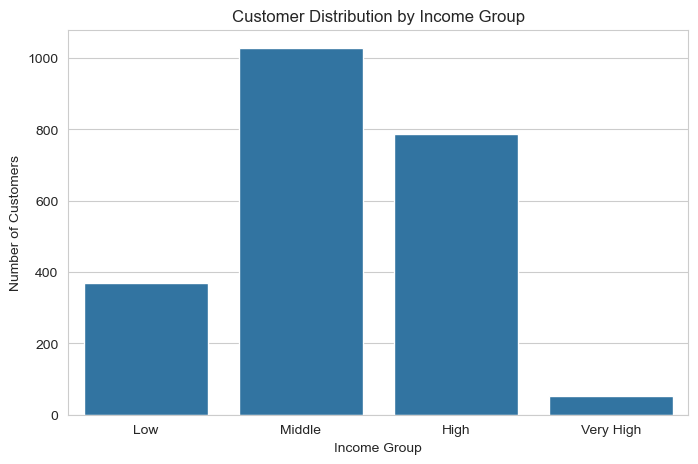

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Income_Group",
    data=df
)

plt.title("Customer Distribution by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Number of Customers")

plt.show()

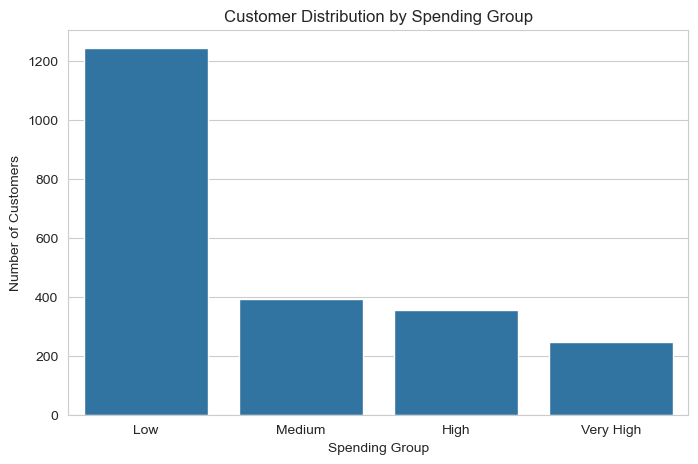

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Spending_Group",
    data=df
)

plt.title("Customer Distribution by Spending Group")
plt.xlabel("Spending Group")
plt.ylabel("Number of Customers")

plt.show()

In [54]:
high_spenders = df[df["Total_Spending"] >= 1500]

high_spenders[[
    "Income",
    "Age",
    "Total_Children",
    "Total_Spending"
]].describe()

,Income,Age,Total_Children,Total_Spending
count,245.000000,245.000000,245.000000,245.000000
mean,79159.087755,57.400000,0.236735,1799.118367
std,13785.615490,12.949271,0.505176,234.933785
min,2447.000000,32.000000,0.000000,1501.000000
25%,72217.000000,48.000000,0.000000,1612.000000
50%,79143.000000,56.000000,0.000000,1734.000000
75%,84169.000000,68.000000,0.000000,1932.000000
max,160803.000000,85.000000,3.000000,2525.000000


# Pricing Psychology and Consumer Behavior Analysis

## 1. Introduction

Understanding why customers spend money is one of the most important goals in marketing and business analytics. Customer purchasing behavior is often influenced by factors such as income level, age, family size, and personal circumstances. Businesses that understand these factors can make better decisions about customer segmentation, product positioning, pricing strategies, and marketing campaigns.

The purpose of this project is to explore customer spending patterns using data analysis techniques in Python. The analysis investigates how demographic characteristics such as age, income, and number of children relate to customer spending behavior. Various statistical summaries and visualizations are used to identify patterns, relationships, and trends within the dataset.

The project also aims to determine the characteristics of high-value customers and provide business recommendations based on the findings. By understanding the factors that influence spending, organizations can improve customer targeting, increase customer retention, and maximize revenue generation.


## 2. Dataset Description

The dataset contains information about customers and their purchasing behavior. Each record represents an individual customer and includes demographic and spending-related variables.

The key variables used in this analysis are:

* **Age:** Customer age in years.
* **Income:** Annual customer income.
* **Total_Children:** Number of children in the customer's household.
* **Total_Spending:** Total amount spent by the customer.

These variables were selected because they provide useful information for understanding customer purchasing behavior and identifying factors associated with higher spending levels.


## 3. Data Cleaning and Preparation

Before conducting the analysis, the dataset was inspected to ensure that the data was suitable for exploration and visualization.

The following preparation steps were performed:

* Loaded the dataset into a Pandas DataFrame.
* Examined the dataset structure and column information.
* Checked for missing values and data quality issues.
* Verified data types for all variables.
* Generated descriptive statistics to understand the distribution of numerical variables.
* Created additional categorical variables such as Age Group, Income Group, and Spending Group to support customer segmentation analysis.

These preparation steps helped ensure that the dataset was ready for exploratory data analysis and business insight generation.


In [55]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   2236 non-null   int64   
 1   Year_Birth           2236 non-null   int64   
 2   Education            2236 non-null   object  
 3   Marital_Status       2236 non-null   object  
 4   Income               2236 non-null   float64 
 5   Kidhome              2236 non-null   int64   
 6   Teenhome             2236 non-null   int64   
 7   Dt_Customer          2236 non-null   object  
 8   Recency              2236 non-null   int64   
 9   MntWines             2236 non-null   int64   
 10  MntFruits            2236 non-null   int64   
 11  MntMeatProducts      2236 non-null   int64   
 12  MntFishProducts      2236 non-null   int64   
 13  MntSweetProducts     2236 non-null   int64   
 14  MntGoldProds         2236 non-null   int64   
 15  NumDealsPurchases    2236 

In [56]:
# Check for missing values
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Age                    0
Total_Children         0
Total_Spending         0
Age_Group              2
Income_Group           0
Spending_Group         0
dtype: int64

## 3.1. Data Cleaning Findings

The dataset contains 2,236 customer records and 35 variables. An inspection of the dataset structure showed that the variables were stored using appropriate data types, including numerical, categorical, and text-based formats.

A missing value assessment revealed that the dataset was generally clean, with no missing values in the original variables used for analysis. Only two missing values were observed in the derived Age_Group variable after age categories were created. Since the number of affected records was extremely small relative to the dataset size, the issue was considered negligible and did not significantly affect the analysis.

Overall, the dataset was found to be suitable for exploratory data analysis and customer behavior investigation.


## 4. Exploratory Data Analysis (EDA)

### 4.1. Distribution Of Customer Age

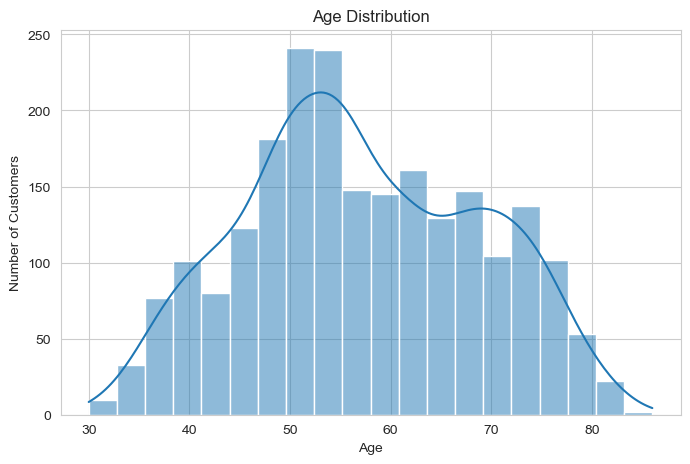

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The age distribution shows that customers are spread across different age groups, with a larger concentration of middle-aged and older individuals.

Most customers fall between 45 and 70 years of age. The distribution indicates that the business attracts mature customers rather than very young consumers.

This suggests that marketing campaigns and product offerings may be more effective when targeted toward middle-aged and older customer segments.

### 4.2. Distribution Of Customer Income

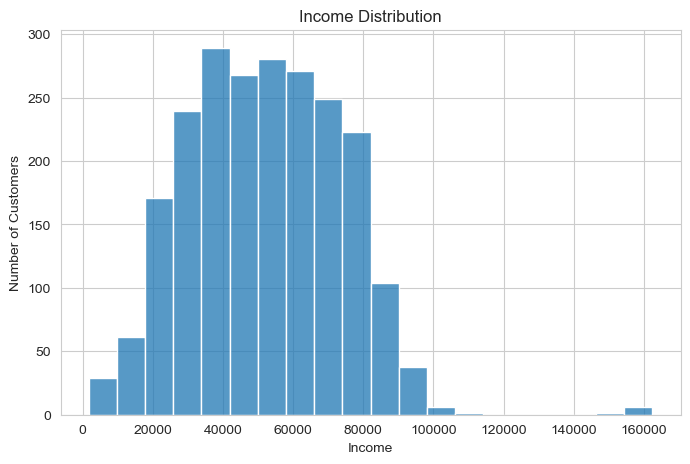

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(df["Income"], bins=20)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The income distribution is slightly right-skewed, meaning most customers earn moderate incomes while a smaller number earn very high incomes.

The average income in the dataset is approximately $51,953. A few customers earn significantly higher incomes, reaching over $160,000.

This indicates the presence of multiple income segments within the customer base, creating opportunities for differentiated marketing strategies.

### 4.3. Spending Distribution

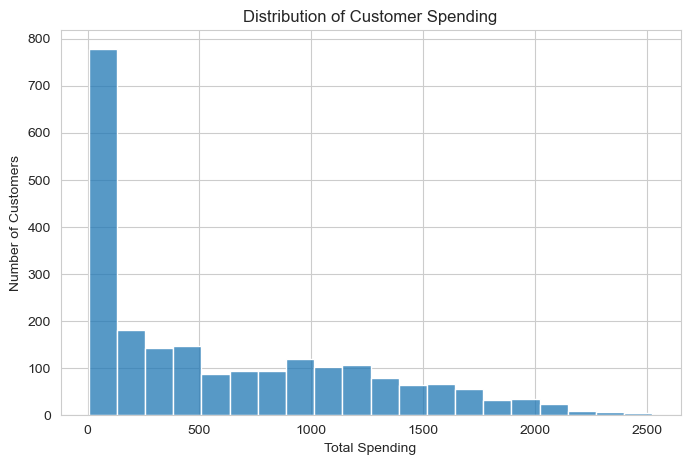

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total_Spending"], bins=20)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

Customer spending is highly right-skewed. Most customers spend relatively small amounts, while a smaller group contributes significantly higher spending values.

The distribution reveals the existence of high-value customers who account for a large portion of total spending.

This pattern is common in consumer markets where a small percentage of customers generate a substantial share of revenue.

### 4.4. Income vs Spending

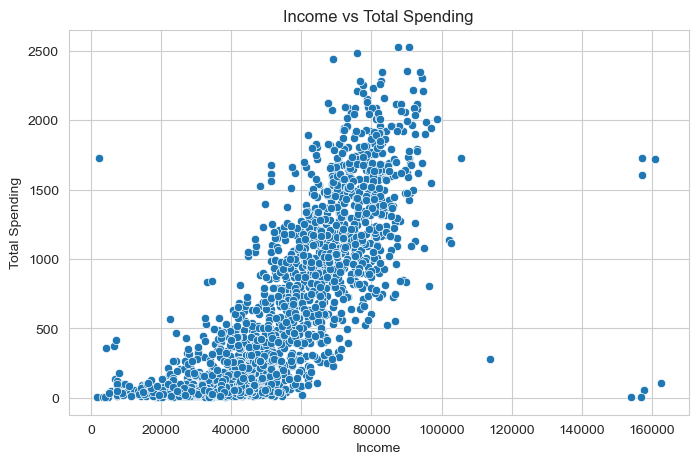

In [60]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Income"],
    y=df["Total_Spending"]
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.show()

### Interpretation

The scatter plot shows a strong positive relationship between income and spending.

As customer income increases, total spending generally increases as well. The correlation coefficient between income and spending is approximately 0.79, indicating a strong positive association.

This suggests that income is one of the most important factors influencing customer spending behavior.

### 4.5. Average Spending by Number of Children

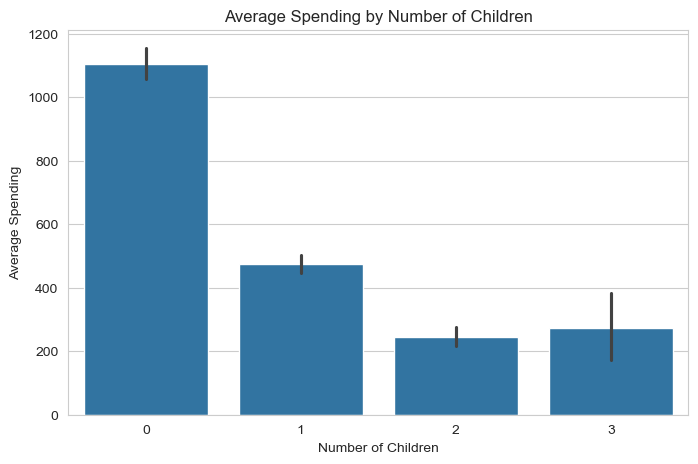

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Total_Children",
    y="Total_Spending",
    data=df
)

plt.title("Average Spending by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Spending")

plt.show()

### Interpretation

Customers without children spend considerably more than customers with children.

Average spending decreases sharply as the number of children increases. Customers with no children spend over $1,100 on average, while customers with one or more children spend significantly less.

This suggests that family responsibilities may reduce discretionary spending.

### 4.6. Average Spending by Age Group

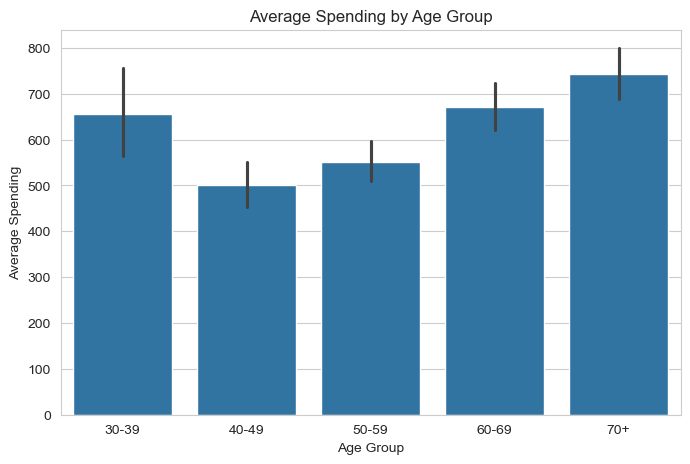

In [62]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Age_Group",
    y="Total_Spending",
    data=df
)

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spending")

plt.show()

### Interpretation

Older customers generally spend more than younger customers.

Customers aged 70 and above record the highest average spending, followed by those aged 60–69. Younger age groups show comparatively lower spending levels.

This indicates that spending power and purchasing behavior tend to increase with age.

### 4.7. Average Spending by Income Group

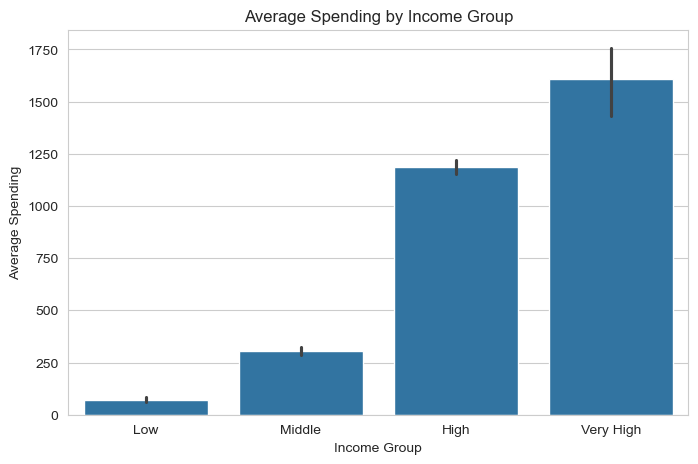

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Income_Group",
    y="Total_Spending",
    data=df
)

plt.title("Average Spending by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Spending")

plt.show()

### Interpretation

Spending rises significantly as income increases.

Customers in the Very High income group spend the most, followed by the High income group. Customers in the Low income category spend very little compared to other groups.

This finding reinforces the strong positive relationship observed between income and spending.

### 4.8. Customer Distribution by Income Group

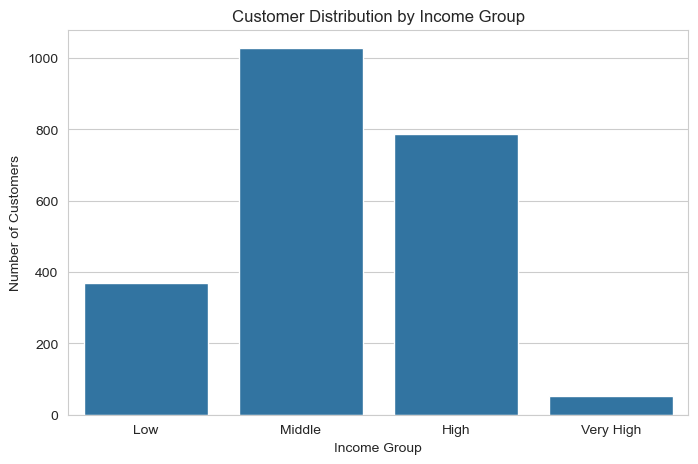

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Income_Group",
    data=df
)

plt.title("Customer Distribution by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

Most customers belong to the Middle and High income groups.

The Very High income category contains the fewest customers, while the Middle income segment represents the largest portion of the customer base.

This suggests that the business serves a broad middle-income market while maintaining a smaller premium customer segment.

### 4.9. Customer Distribution by Spending Group

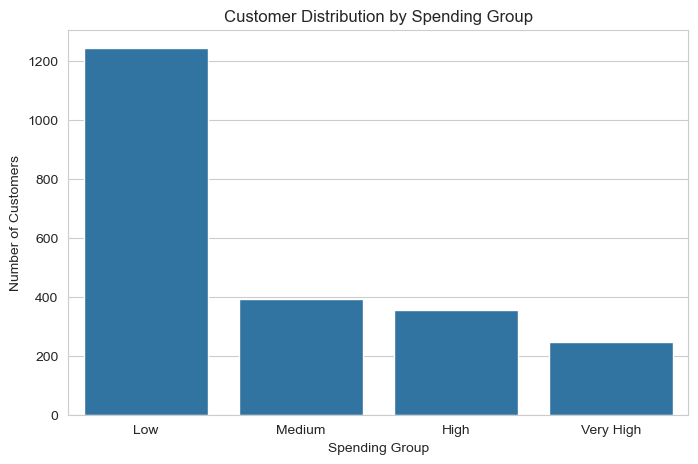

In [65]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Spending_Group",
    data=df
)

plt.title("Customer Distribution by Spending Group")
plt.xlabel("Spending Group")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The majority of customers belong to the Low Spending group.

As spending levels increase, the number of customers decreases. The Very High Spending segment contains the smallest number of customers.

This demonstrates that a small group of customers contributes disproportionately to overall sales revenue.

## 5. High-Value Customer Analysis

In [66]:
high_spenders = df[df["Total_Spending"] >= 1500]

high_spenders[
    ["Income",
     "Age",
     "Total_Children",
     "Total_Spending"]
].describe()

,Income,Age,Total_Children,Total_Spending
count,245.000000,245.000000,245.000000,245.000000
mean,79159.087755,57.400000,0.236735,1799.118367
std,13785.615490,12.949271,0.505176,234.933785
min,2447.000000,32.000000,0.000000,1501.000000
25%,72217.000000,48.000000,0.000000,1612.000000
50%,79143.000000,56.000000,0.000000,1734.000000
75%,84169.000000,68.000000,0.000000,1932.000000
max,160803.000000,85.000000,3.000000,2525.000000


### Interpretation

High-value customers tend to have higher incomes, older ages, and fewer children.

The average income of high-value customers is approximately $79,159, while their average age is about 57 years. Most high-value customers have no children or very small household sizes.

These characteristics suggest that affluent older customers with fewer financial responsibilities represent the most profitable segment of the customer base.

##  6. Key Findings

The analysis revealed several important insights about customer spending behavior.

1. Income has the strongest relationship with spending. Customers with higher incomes consistently spend more than lower-income customers.

2. Age has only a weak positive relationship with spending. While older customers tend to spend slightly more, age alone is not a strong predictor of spending behavior.

3. Customers without children spend significantly more than customers with one or more children.

4. High-income customers account for the majority of high-spending customers in the dataset.

5. The highest-value customers are generally older, wealthier, and have fewer family responsibilities.

6. Most customers fall into the low and medium spending categories, while relatively few customers belong to the very high spending segment.

##  7. Business Recommendations

Based on the findings, the following recommendations are suggested:

1. Focus marketing efforts on high-income customer segments, as they generate the highest spending levels.

2. Develop premium products and personalized offers targeted at affluent customers.

3. Create loyalty programs designed to retain high-value customers and encourage repeat purchases.

4. Segment customers by income and spending behavior to improve marketing efficiency and campaign performance.

5. Offer family-oriented promotions to customers with children in order to increase spending among lower-spending household groups.

6. Continue collecting customer demographic and purchasing data to support data-driven business decisions.

## 8. Conclusion

This project explored customer spending behavior using demographic variables such as age, income, and number of children.

The analysis showed that income is the strongest factor influencing customer spending. Customers with higher incomes generally spend significantly more than lower-income customers. Age was found to have only a weak relationship with spending, while customers with fewer children tended to spend more.

The high-value customer analysis revealed that the most profitable customers are typically older, wealthier, and have smaller household sizes.

These findings demonstrate how data analysis can help businesses understand customer behavior, improve customer segmentation, and make better marketing and pricing decisions.